In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# INTER STORY

In [51]:
df1 = pd.read_excel(r'pred_res\g14_inter_story_LAST3_FINAL.xlsx')
df1['true_label'] = df1['true_label'].apply(lambda x: x.upper())

In [52]:
LABELS = ["NONE", "CONFLICT", "DEPENDS_ON", "DUPLICATE"]
TRUE = "true_label"
PRED = "predicted_relation"
SOURCE = "data_source"

d = df1.dropna(subset=[TRUE, PRED, SOURCE]).copy()

# safety normalization, even if labels are already clean
d[TRUE] = d[TRUE].str.strip().str.upper()
d[PRED] = d[PRED].str.strip().str.upper()
d[SOURCE] = d[SOURCE].str.strip().str.lower()

print(d.shape)
print('\n')
print(d[SOURCE].value_counts())
print('\n')
print(d[TRUE].value_counts())
print('\n')
print(d[PRED].value_counts())

(248, 10)


natural      132
synthetic    116
Name: data_source, dtype: int64


NONE          64
CONFLICT      63
DEPENDS_ON    62
DUPLICATE     59
Name: true_label, dtype: int64


NONE          80
CONFLICT      61
DUPLICATE     58
DEPENDS_ON    49
Name: predicted_relation, dtype: int64


### 1. Metrics for synthetic, natural, and total

In [53]:
def evaluate_subset(data, name):
    y_true = data[TRUE]
    y_pred = data[PRED]

    return {
        "subset": name,
        "n": len(data),
        "accuracy": accuracy_score(y_true, y_pred),
#         "micro_f1": f1_score(y_true, y_pred, labels=LABELS, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, labels=LABELS, average="weighted", zero_division=0),
    }

rows = []

for src in ["synthetic", "natural"]:
    rows.append(evaluate_subset(d[d[SOURCE] == src], src))

rows.append(evaluate_subset(d, "total"))

metrics_table = pd.DataFrame(rows).round(4)
metrics_table

,subset,n,accuracy,macro_f1,weighted_f1
0,synthetic,116,0.9828,0.7329,0.9866
1,natural,132,0.8182,0.7980,0.8129
2,total,248,0.8952,0.8955,0.8949


### 2. Full classification reports

In [54]:
for name, data in {
    "synthetic": d[d[SOURCE] == "synthetic"],
    "natural": d[d[SOURCE] == "natural"],
    "total": d
}.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)
    print(classification_report(
        data[TRUE],
        data[PRED],
        labels=LABELS,
        zero_division=0
    ))

SYNTHETIC
              precision    recall  f1-score   support

        NONE       0.00      0.00      0.00         0
    CONFLICT       1.00      1.00      1.00        58
  DEPENDS_ON       1.00      0.89      0.94        19
   DUPLICATE       0.97      1.00      0.99        39

    accuracy                           0.98       116
   macro avg       0.74      0.72      0.73       116
weighted avg       0.99      0.98      0.99       116

NATURAL
              precision    recall  f1-score   support

        NONE       0.77      0.95      0.85        64
    CONFLICT       1.00      0.60      0.75         5
  DEPENDS_ON       0.88      0.65      0.75        43
   DUPLICATE       0.89      0.80      0.84        20

    accuracy                           0.82       132
   macro avg       0.88      0.75      0.80       132
weighted avg       0.83      0.82      0.81       132

TOTAL
              precision    recall  f1-score   support

        NONE       0.76      0.95      0.85        

### 3. True vs predicted label distribution

In [55]:
def label_distribution(data, name):
    out = pd.DataFrame({
        "true_count": data[TRUE].value_counts().reindex(LABELS, fill_value=0),
        "pred_count": data[PRED].value_counts().reindex(LABELS, fill_value=0),
    })
    out["true_%"] = (out["true_count"] / len(data) * 100).round(2)
    out["pred_%"] = (out["pred_count"] / len(data) * 100).round(2)
    out["pred_minus_true"] = out["pred_count"] - out["true_count"]
    out.insert(0, "subset", name)
    return out

dist_table = pd.concat([
    label_distribution(d[d[SOURCE] == "synthetic"], "synthetic"),
    label_distribution(d[d[SOURCE] == "natural"], "natural"),
    label_distribution(d, "total")
])

dist_table

,subset,true_count,pred_count,true_%,pred_%,pred_minus_true
NONE,synthetic,0,1,0.00,0.86,1
CONFLICT,synthetic,58,58,50.00,50.00,0
DEPENDS_ON,synthetic,19,17,16.38,14.66,-2
DUPLICATE,synthetic,39,40,33.62,34.48,1
NONE,natural,64,79,48.48,59.85,15
CONFLICT,natural,5,3,3.79,2.27,-2
DEPENDS_ON,natural,43,32,32.58,24.24,-11
DUPLICATE,natural,20,18,15.15,13.64,-2
NONE,total,64,80,25.81,32.26,16
CONFLICT,total,63,61,25.40,24.60,-2


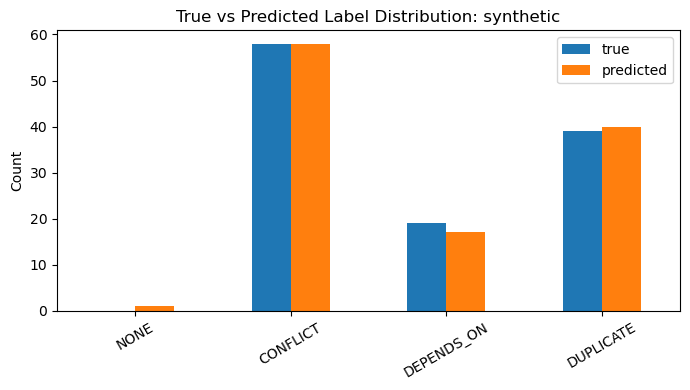

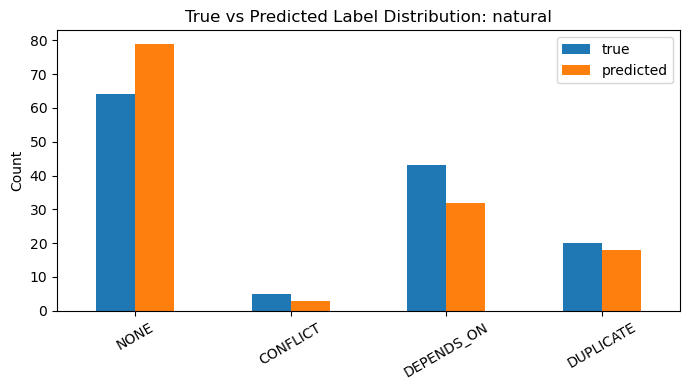

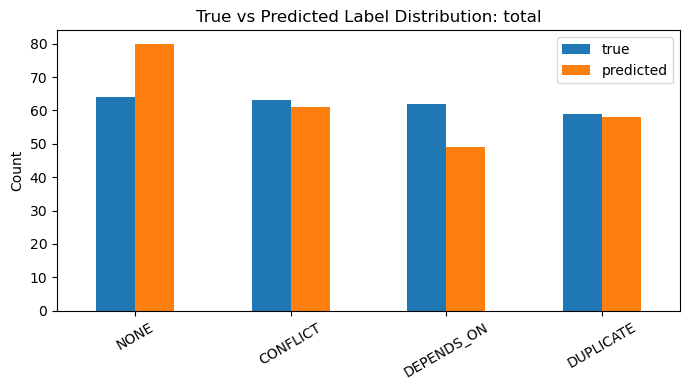

In [56]:
for name, data in {
    "synthetic": d[d[SOURCE] == "synthetic"],
    "natural": d[d[SOURCE] == "natural"],
    "total": d
}.items():
    dist = pd.DataFrame({
        "true": data[TRUE].value_counts().reindex(LABELS, fill_value=0),
        "predicted": data[PRED].value_counts().reindex(LABELS, fill_value=0)
    })

    dist.plot(kind="bar", figsize=(7, 4))
    plt.title(f"True vs Predicted Label Distribution: {name}")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### 4. Confusion matrices

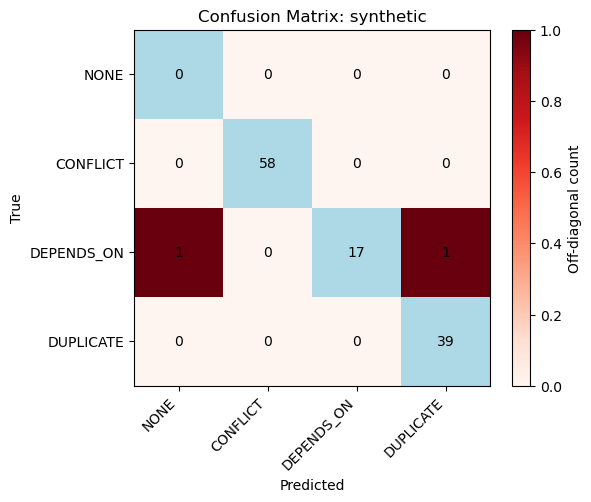

,NONE,CONFLICT,DEPENDS_ON,DUPLICATE
NONE,0,0,0,0
CONFLICT,0,58,0,0
DEPENDS_ON,1,0,17,1
DUPLICATE,0,0,0,39


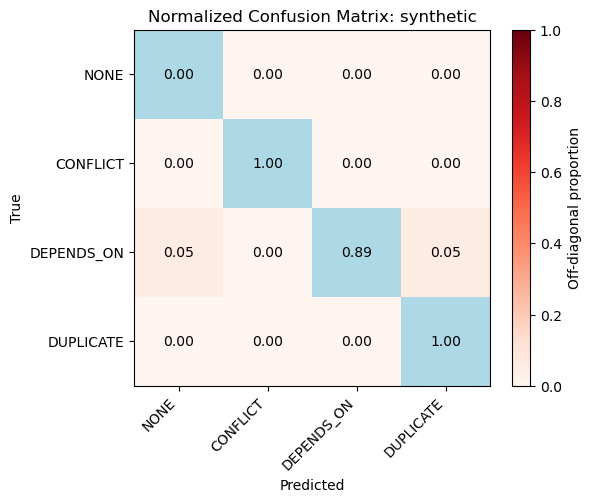

,NONE,CONFLICT,DEPENDS_ON,DUPLICATE
NONE,0.000000,0.0,0.000000,0.000000
CONFLICT,0.000000,1.0,0.000000,0.000000
DEPENDS_ON,0.052632,0.0,0.894737,0.052632
DUPLICATE,0.000000,0.0,0.000000,1.000000


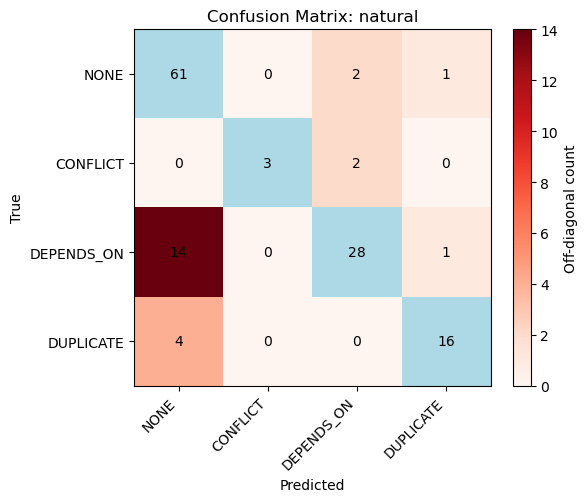

,NONE,CONFLICT,DEPENDS_ON,DUPLICATE
NONE,61,0,2,1
CONFLICT,0,3,2,0
DEPENDS_ON,14,0,28,1
DUPLICATE,4,0,0,16


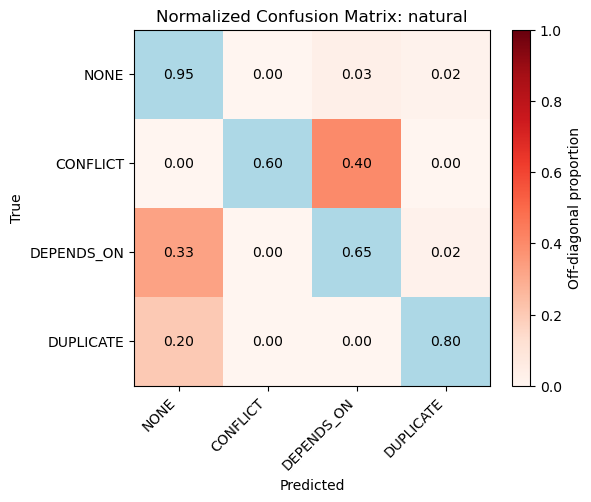

,NONE,CONFLICT,DEPENDS_ON,DUPLICATE
NONE,0.953125,0.0,0.031250,0.015625
CONFLICT,0.000000,0.6,0.400000,0.000000
DEPENDS_ON,0.325581,0.0,0.651163,0.023256
DUPLICATE,0.200000,0.0,0.000000,0.800000


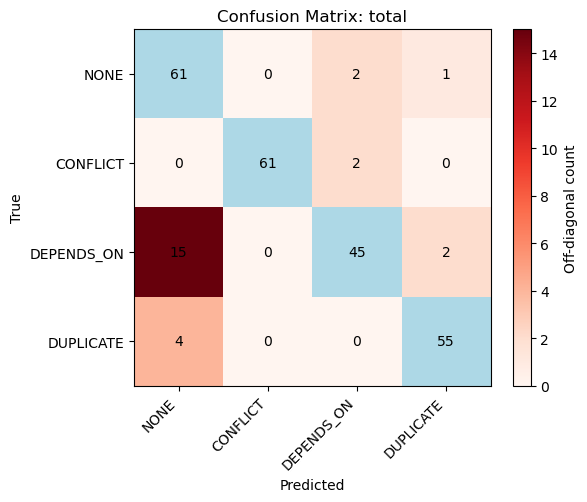

,NONE,CONFLICT,DEPENDS_ON,DUPLICATE
NONE,61,0,2,1
CONFLICT,0,61,2,0
DEPENDS_ON,15,0,45,2
DUPLICATE,4,0,0,55


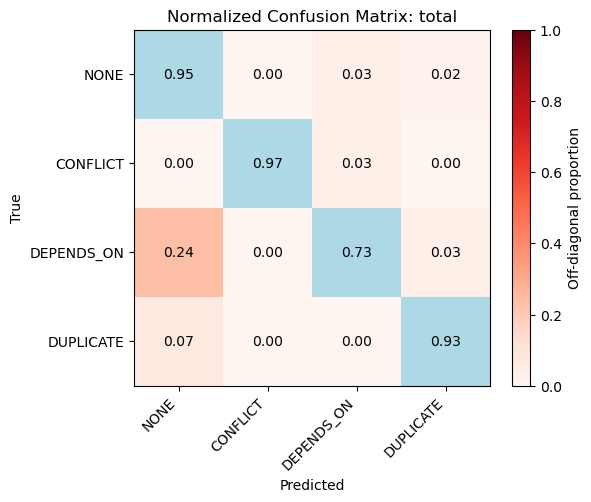

,NONE,CONFLICT,DEPENDS_ON,DUPLICATE
NONE,0.953125,0.000000,0.031250,0.015625
CONFLICT,0.000000,0.968254,0.031746,0.000000
DEPENDS_ON,0.241935,0.000000,0.725806,0.032258
DUPLICATE,0.067797,0.000000,0.000000,0.932203


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix

def plot_cm(data, name, normalize=False):
    cm = confusion_matrix(
        data[TRUE],
        data[PRED],
        labels=LABELS,
        normalize="true" if normalize else None
    )

    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    values = cm_df.to_numpy(dtype=float)

    plt.figure(figsize=(6, 5))

    # Non-diagonal cells
    off_diag = values.copy()
    np.fill_diagonal(off_diag, np.nan)

    vmax = 1 if normalize else max(np.nanmax(off_diag), 1)

    im = plt.imshow(
        off_diag,
        cmap="Reds",
        vmin=0,
        vmax=vmax
    )

    # Diagonal cells with fixed color
    diag = np.full_like(values, np.nan)
    np.fill_diagonal(diag, 1)

    plt.imshow(
        diag,
        cmap=ListedColormap(["lightblue"]),
        vmin=0,
        vmax=1
    )

    plt.title(("Normalized " if normalize else "") + f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
    plt.yticks(range(len(LABELS)), LABELS)

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            value = cm_df.iloc[i, j]
            text = f"{value:.2f}" if normalize else str(int(value))
            plt.text(j, i, text, ha="center", va="center")

    plt.colorbar(
        im,
        label="Off-diagonal proportion" if normalize else "Off-diagonal count"
    )

    plt.tight_layout()
    suffix = "normalized" if normalize else "counts"
    plt.savefig(
        f"confusion_matrix_{name}_{suffix}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return cm_df


for name, data in {
    "synthetic": d[d[SOURCE] == "synthetic"],
    "natural": d[d[SOURCE] == "natural"],
    "total": d
}.items():
    display(plot_cm(data, name, normalize=False))
    display(plot_cm(data, name, normalize=True))

### 5. Error type tables

In [58]:
def error_table(data, name):
    tmp = data.copy()
    tmp["correct"] = tmp[TRUE] == tmp[PRED]

    out = (
        tmp[~tmp["correct"]]
        .groupby([TRUE, PRED])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    out.insert(0, "subset", name)
    return out

errors = pd.concat([
    error_table(d[d[SOURCE] == "synthetic"], "synthetic"),
    error_table(d[d[SOURCE] == "natural"], "natural"),
    error_table(d, "total")
])

errors

,subset,true_label,predicted_relation,count
0,synthetic,DEPENDS_ON,DUPLICATE,1
1,synthetic,DEPENDS_ON,NONE,1
2,natural,DEPENDS_ON,NONE,14
3,natural,DUPLICATE,NONE,4
0,natural,CONFLICT,DEPENDS_ON,2
4,natural,NONE,DEPENDS_ON,2
1,natural,DEPENDS_ON,DUPLICATE,1
5,natural,NONE,DUPLICATE,1
2,total,DEPENDS_ON,NONE,15
3,total,DUPLICATE,NONE,4


### 6. Accuracy by true label and source

In [59]:
d["correct"] = d[TRUE] == d[PRED]

acc_by_label_source = (
    d.groupby([SOURCE, TRUE])
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

acc_by_label_source["accuracy"] = acc_by_label_source["accuracy"].round(4)
acc_by_label_source

,data_source,true_label,n,correct,accuracy
0,natural,CONFLICT,5,3,0.6000
1,natural,DEPENDS_ON,43,28,0.6512
2,natural,DUPLICATE,20,16,0.8000
3,natural,NONE,64,61,0.9531
4,synthetic,CONFLICT,58,58,1.0000
5,synthetic,DEPENDS_ON,19,17,0.8947
6,synthetic,DUPLICATE,39,39,1.0000


### 7. Response time by correctness

In [60]:
if "response_time_sec" in d.columns:
    time_table = (
        d.groupby([SOURCE, "correct"])
        .agg(
            n=("response_time_sec", "size"),
            mean_time=("response_time_sec", "mean"),
            median_time=("response_time_sec", "median"),
            max_time=("response_time_sec", "max")
        )
        .round(3)
        .reset_index()
    )

    display(time_table)

,data_source,correct,n,mean_time,median_time,max_time
0,natural,False,24,0.861,0.786,1.921
1,natural,True,108,0.851,0.785,1.920
2,synthetic,False,2,1.152,1.152,1.171
3,synthetic,True,114,0.931,0.906,1.647


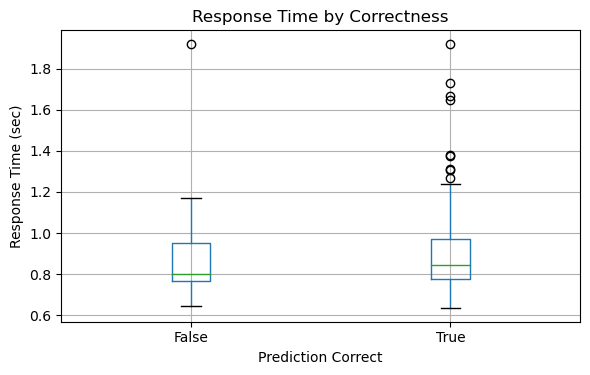

In [61]:
if "response_time_sec" in d.columns:
    d.boxplot(column="response_time_sec", by="correct", figsize=(6, 4))
    plt.title("Response Time by Correctness")
    plt.suptitle("")
    plt.xlabel("Prediction Correct")
    plt.ylabel("Response Time (sec)")
    plt.tight_layout()
    plt.savefig(
        "response_time_by_correctness.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

### 8. Inspect specific wrong cases

In [62]:
cols = [
    "pair_id_1",
    "pair_id_2",
    "transformation",
    "story_1_text",
    "story_2_text",
    TRUE,
    PRED,
    SOURCE,
    "llm_reason",
    "response_time_sec"
]

cols = [c for c in cols if c in d.columns]

wrong_cases = d[d[TRUE] != d[PRED]][cols]
wrong_cases.head(30)

,pair_id_1,pair_id_2,transformation,story_1_text,story_2_text,true_label,predicted_relation,data_source,llm_reason,response_time_sec
14,0,66,None,"As a Publisher, I want to publish a dataset, s...","As a Publisher, I want to have private data pa...",NONE,DUPLICATE,natural,Both stories describe the same core intent of ...,0.764714
28,16,20,None,"As a Publisher, I want to publish a data packa...","As a Publisher, I want to be able to preview t...",NONE,DEPENDS_ON,natural,Story B represents a distinct refinement and t...,0.938154
60,12,16,None,"As a Publisher, I want to data to be validated...","As a Publisher, I want to publish a data packa...",NONE,DEPENDS_ON,natural,Story A describes a validation requirement for...,0.766314
87,30,30,PREREQUISITE_TRANSFORMATION,"As a Consumer, I want to download the data pac...","As a Data Provider, I want to publish a data p...",DEPENDS_ON,NONE,synthetic,The stories represent two sides of the same fu...,1.170875
91,31,31,PREREQUISITE_TRANSFORMATION,"As a Developer, I want to use data package as ...","As a Developer, I want the data package to be ...",DEPENDS_ON,DUPLICATE,synthetic,Both stories describe the same requirement for...,1.133604
187,1,22,None,"As a Publisher, I want to publish a dataset, s...","As a publisher, I want to show the world how m...",DUPLICATE,NONE,natural,Story A defines the functional action of publi...,0.721650
188,1,23,None,"As a Publisher, I want to publish a dataset, s...","As a consumer, I want to view the data package...",DEPENDS_ON,NONE,natural,The stories involve different actors (Publishe...,1.020404
197,2,51,None,"As a Publisher, I want to sign up for an accou...","As a Consumer, I want to see a publisher's pro...",DEPENDS_ON,NONE,natural,The stories involve different actors (Publishe...,0.715585
205,7,66,None,"As a Publisher, I want to configure my client,...","As a Publisher, I want to have private data pa...",DEPENDS_ON,NONE,natural,The stories describe different functional obje...,0.809405
209,10,18,None,"As a Publisher, I want to permanently delete a...","As a Publisher, I want to be able to restore t...",CONFLICT,DEPENDS_ON,natural,Story B describes an action to restore an enti...,0.832164


### 9. Worst error types with examples

In [63]:
top_error_examples = (
    d[d[TRUE] != d[PRED]]
    .groupby([TRUE, PRED], group_keys=False)
    .head(3)
)

top_error_examples[cols]

,pair_id_1,pair_id_2,transformation,story_1_text,story_2_text,true_label,predicted_relation,data_source,llm_reason,response_time_sec
14,0,66,None,"As a Publisher, I want to publish a dataset, s...","As a Publisher, I want to have private data pa...",NONE,DUPLICATE,natural,Both stories describe the same core intent of ...,0.764714
28,16,20,None,"As a Publisher, I want to publish a data packa...","As a Publisher, I want to be able to preview t...",NONE,DEPENDS_ON,natural,Story B represents a distinct refinement and t...,0.938154
60,12,16,None,"As a Publisher, I want to data to be validated...","As a Publisher, I want to publish a data packa...",NONE,DEPENDS_ON,natural,Story A describes a validation requirement for...,0.766314
87,30,30,PREREQUISITE_TRANSFORMATION,"As a Consumer, I want to download the data pac...","As a Data Provider, I want to publish a data p...",DEPENDS_ON,NONE,synthetic,The stories represent two sides of the same fu...,1.170875
91,31,31,PREREQUISITE_TRANSFORMATION,"As a Developer, I want to use data package as ...","As a Developer, I want the data package to be ...",DEPENDS_ON,DUPLICATE,synthetic,Both stories describe the same requirement for...,1.133604
187,1,22,None,"As a Publisher, I want to publish a dataset, s...","As a publisher, I want to show the world how m...",DUPLICATE,NONE,natural,Story A defines the functional action of publi...,0.721650
188,1,23,None,"As a Publisher, I want to publish a dataset, s...","As a consumer, I want to view the data package...",DEPENDS_ON,NONE,natural,The stories involve different actors (Publishe...,1.020404
197,2,51,None,"As a Publisher, I want to sign up for an accou...","As a Consumer, I want to see a publisher's pro...",DEPENDS_ON,NONE,natural,The stories involve different actors (Publishe...,0.715585
209,10,18,None,"As a Publisher, I want to permanently delete a...","As a Publisher, I want to be able to restore t...",CONFLICT,DEPENDS_ON,natural,Story B describes an action to restore an enti...,0.832164
210,10,19,None,"As a Publisher, I want to permanently delete a...","As a Publisher, I want to undelete the deleted...",CONFLICT,DEPENDS_ON,natural,Story B involves restoring or reversing the ac...,0.712626


# INTRA STORY

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [65]:
df2 = pd.read_excel(r'pred_res\intra_story\g14_intra_story_LAST3_FINAL.xlsx')

LABELS = ["NONE", "BLOCKS", "ENABLES"]

TRUE = "True_label"
PRED = "predicted_relation"
SOURCE = "data_source"

d = df2.dropna(subset=[TRUE, PRED, SOURCE]).copy()

d[TRUE] = d[TRUE].str.strip().str.upper()
d[PRED] = d[PRED].str.strip().str.upper()
d[SOURCE] = d[SOURCE].str.strip().str.lower()

print("Shape:", d.shape)
print("\nSource distribution:")
print(d[SOURCE].value_counts())
print("\nTrue label distribution:")
print(d[TRUE].value_counts())
print("\nPredicted label distribution:")
print(d[PRED].value_counts())

Shape: (214, 19)

Source distribution:
natural      148
synthetic     66
Name: data_source, dtype: int64

True label distribution:
ENABLES    73
NONE       73
BLOCKS     68
Name: True_label, dtype: int64

Predicted label distribution:
ENABLES    82
BLOCKS     68
NONE       64
Name: predicted_relation, dtype: int64


### 1. Metrics for synthetic, natural, and total

In [66]:
def evaluate_subset(data, name):
    y_true = data[TRUE]
    y_pred = data[PRED]

    return {
        "subset": name,
        "n": len(data),
        "accuracy": accuracy_score(y_true, y_pred),
#         "micro_f1": f1_score(y_true, y_pred, labels=LABELS, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, labels=LABELS, average="weighted", zero_division=0),
    }

metrics_table = pd.DataFrame([
    evaluate_subset(d[d[SOURCE] == "synthetic"], "synthetic"),
    evaluate_subset(d[d[SOURCE] == "natural"], "natural"),
    evaluate_subset(d, "total")
]).round(4)

metrics_table

,subset,n,accuracy,macro_f1,weighted_f1
0,synthetic,66,1.0000,0.3333,1.0000
1,natural,148,0.8311,0.8854,0.8304
2,total,214,0.8832,0.8854,0.8827


### 2. Full classification reports

In [67]:
for name, data in {
    "synthetic": d[d[SOURCE] == "synthetic"],
    "natural": d[d[SOURCE] == "natural"],
    "total": d
}.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)
    print(classification_report(
        data[TRUE],
        data[PRED],
        labels=LABELS,
        zero_division=0
    ))

SYNTHETIC
              precision    recall  f1-score   support

        NONE       0.00      0.00      0.00         0
      BLOCKS       1.00      1.00      1.00        66
     ENABLES       0.00      0.00      0.00         0

    accuracy                           1.00        66
   macro avg       0.33      0.33      0.33        66
weighted avg       1.00      1.00      1.00        66

NATURAL
              precision    recall  f1-score   support

        NONE       0.88      0.77      0.82        73
      BLOCKS       1.00      1.00      1.00         2
     ENABLES       0.79      0.89      0.84        73

    accuracy                           0.83       148
   macro avg       0.89      0.89      0.89       148
weighted avg       0.84      0.83      0.83       148

TOTAL
              precision    recall  f1-score   support

        NONE       0.88      0.77      0.82        73
      BLOCKS       1.00      1.00      1.00        68
     ENABLES       0.79      0.89      0.84        

### 3. True vs predicted label distribution

In [68]:
def label_distribution(data, name):
    out = pd.DataFrame({
        "true_count": data[TRUE].value_counts().reindex(LABELS, fill_value=0),
        "pred_count": data[PRED].value_counts().reindex(LABELS, fill_value=0),
    })

    out["true_%"] = (out["true_count"] / len(data) * 100).round(2)
    out["pred_%"] = (out["pred_count"] / len(data) * 100).round(2)
    out["pred_minus_true"] = out["pred_count"] - out["true_count"]
    out.insert(0, "subset", name)

    return out

dist_table = pd.concat([
    label_distribution(d[d[SOURCE] == "synthetic"], "synthetic"),
    label_distribution(d[d[SOURCE] == "natural"], "natural"),
    label_distribution(d, "total")
])

dist_table

,subset,true_count,pred_count,true_%,pred_%,pred_minus_true
NONE,synthetic,0,0,0.00,0.00,0
BLOCKS,synthetic,66,66,100.00,100.00,0
ENABLES,synthetic,0,0,0.00,0.00,0
NONE,natural,73,64,49.32,43.24,-9
BLOCKS,natural,2,2,1.35,1.35,0
ENABLES,natural,73,82,49.32,55.41,9
NONE,total,73,64,34.11,29.91,-9
BLOCKS,total,68,68,31.78,31.78,0
ENABLES,total,73,82,34.11,38.32,9


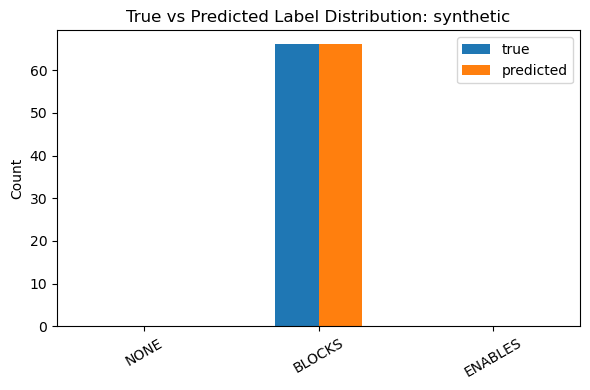

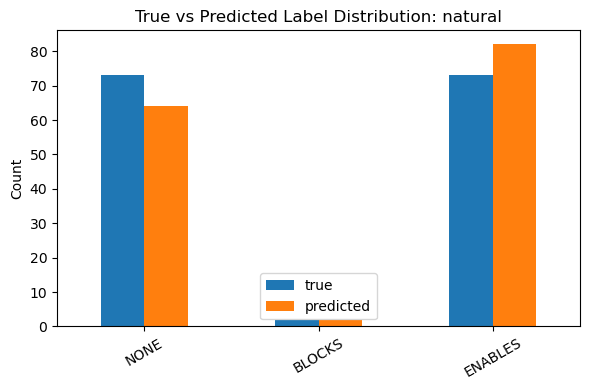

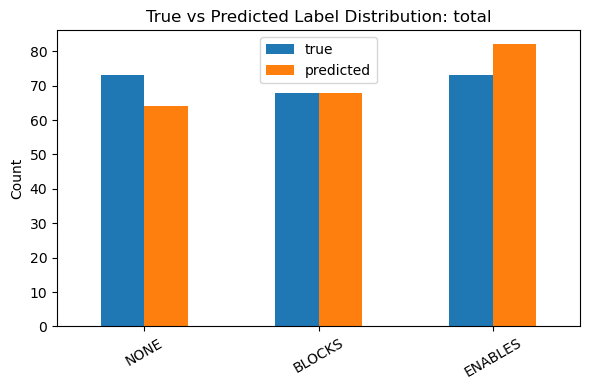

In [69]:
for name, data in {
    "synthetic": d[d[SOURCE] == "synthetic"],
    "natural": d[d[SOURCE] == "natural"],
    "total": d
}.items():
    dist = pd.DataFrame({
        "true": data[TRUE].value_counts().reindex(LABELS, fill_value=0),
        "predicted": data[PRED].value_counts().reindex(LABELS, fill_value=0)
    })

    dist.plot(kind="bar", figsize=(6, 4))
    plt.title(f"True vs Predicted Label Distribution: {name}")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### 4. Confusion matrices

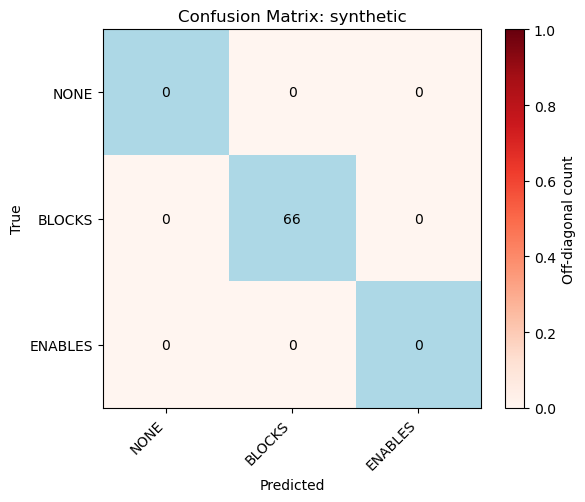

,NONE,BLOCKS,ENABLES
NONE,0,0,0
BLOCKS,0,66,0
ENABLES,0,0,0


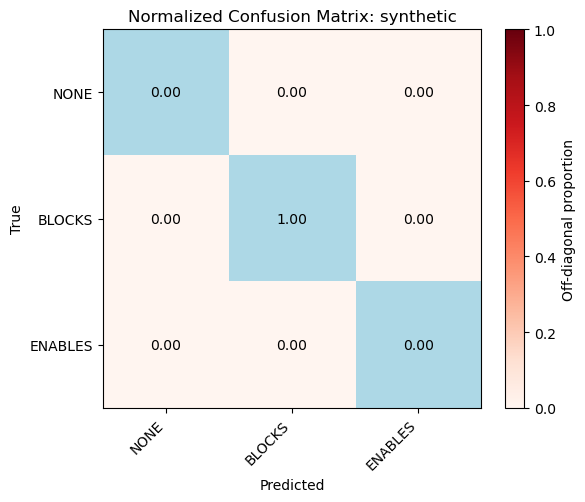

,NONE,BLOCKS,ENABLES
NONE,0.0,0.0,0.0
BLOCKS,0.0,1.0,0.0
ENABLES,0.0,0.0,0.0


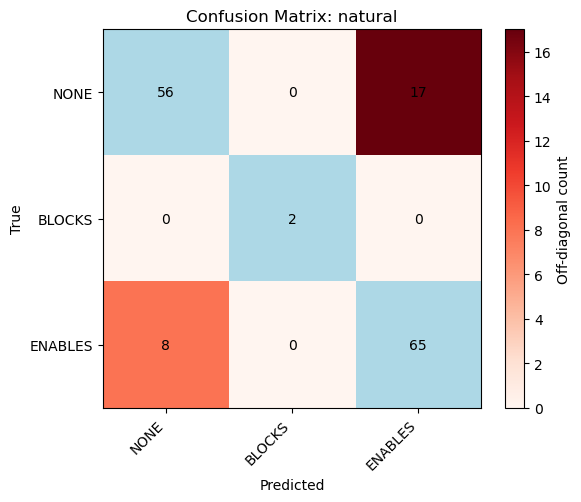

,NONE,BLOCKS,ENABLES
NONE,56,0,17
BLOCKS,0,2,0
ENABLES,8,0,65


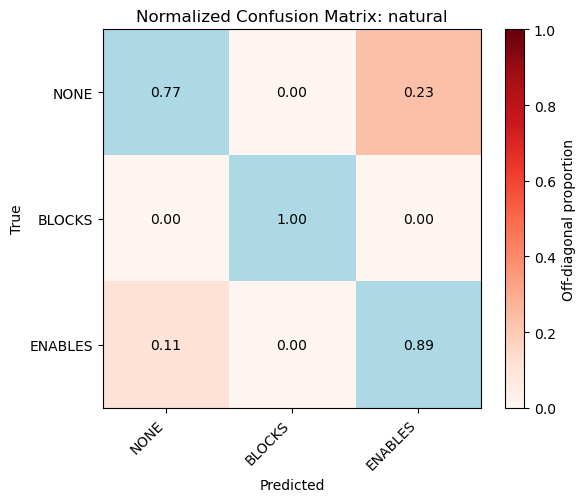

,NONE,BLOCKS,ENABLES
NONE,0.767123,0.0,0.232877
BLOCKS,0.000000,1.0,0.000000
ENABLES,0.109589,0.0,0.890411


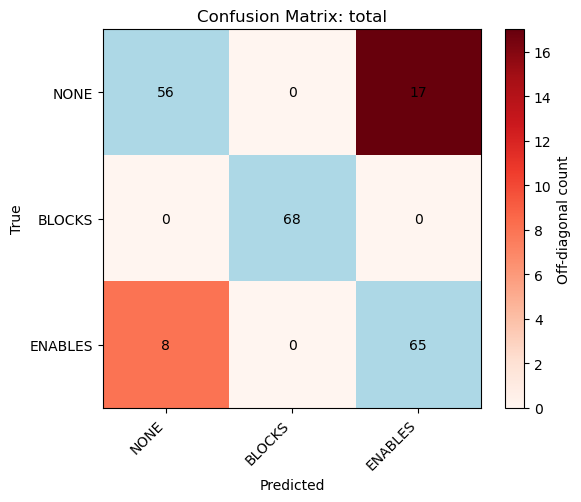

,NONE,BLOCKS,ENABLES
NONE,56,0,17
BLOCKS,0,68,0
ENABLES,8,0,65


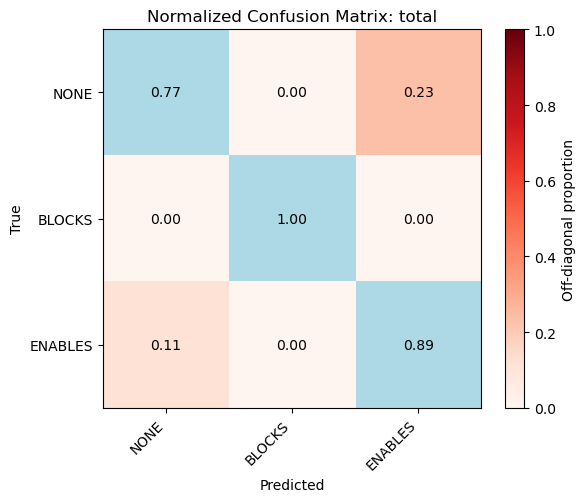

,NONE,BLOCKS,ENABLES
NONE,0.767123,0.0,0.232877
BLOCKS,0.000000,1.0,0.000000
ENABLES,0.109589,0.0,0.890411


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix

def plot_cm(data, name, normalize=False):
    cm = confusion_matrix(
        data[TRUE],
        data[PRED],
        labels=LABELS,
        normalize="true" if normalize else None
    )

    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    values = cm_df.to_numpy(dtype=float)

    plt.figure(figsize=(6, 5))

    # Non-diagonal cells
    off_diag = values.copy()
    np.fill_diagonal(off_diag, np.nan)

    vmax = 1 if normalize else max(np.nanmax(off_diag), 1)

    im = plt.imshow(
        off_diag,
        cmap="Reds",
        vmin=0,
        vmax=vmax
    )

    # Diagonal cells with fixed color
    diag = np.full_like(values, np.nan)
    np.fill_diagonal(diag, 1)

    plt.imshow(
        diag,
        cmap=ListedColormap(["lightblue"]),
        vmin=0,
        vmax=1
    )

    plt.title(("Normalized " if normalize else "") + f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
    plt.yticks(range(len(LABELS)), LABELS)

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            value = cm_df.iloc[i, j]
            text = f"{value:.2f}" if normalize else str(int(value))
            plt.text(j, i, text, ha="center", va="center")

    plt.colorbar(
        im,
        label="Off-diagonal proportion" if normalize else "Off-diagonal count"
    )

    plt.tight_layout()
    suffix = "normalized" if normalize else "counts"
    plt.savefig(
        f"confusion_matrix_{name}_{suffix}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return cm_df


for name, data in {
    "synthetic": d[d[SOURCE] == "synthetic"],
    "natural": d[d[SOURCE] == "natural"],
    "total": d
}.items():
    display(plot_cm(data, name, normalize=False))
    display(plot_cm(data, name, normalize=True))

### 5. Error type table

In [71]:
def error_table(data, name):
    tmp = data.copy()
    tmp["correct"] = tmp[TRUE] == tmp[PRED]

    out = (
        tmp[~tmp["correct"]]
        .groupby([TRUE, PRED])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    out.insert(0, "subset", name)
    return out

errors = pd.concat([
    error_table(d[d[SOURCE] == "synthetic"], "synthetic"),
    error_table(d[d[SOURCE] == "natural"], "natural"),
    error_table(d, "total")
])

errors

,subset,True_label,predicted_relation,count
1,natural,NONE,ENABLES,17
0,natural,ENABLES,NONE,8
1,total,NONE,ENABLES,17
0,total,ENABLES,NONE,8


### 6. Accuracy by true label and source

In [72]:
d["correct"] = d[TRUE] == d[PRED]

acc_by_label_source = (
    d.groupby([SOURCE, TRUE])
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

acc_by_label_source["accuracy"] = acc_by_label_source["accuracy"].round(4)
acc_by_label_source

,data_source,True_label,n,correct,accuracy
0,natural,BLOCKS,2,2,1.0000
1,natural,ENABLES,73,65,0.8904
2,natural,NONE,73,56,0.7671
3,synthetic,BLOCKS,66,66,1.0000


### 7. Accuracy by relation direction

In [73]:
if "relation_direction" in d.columns:
    acc_by_direction = (
        d.groupby(["relation_direction", TRUE])
        .agg(
            n=("correct", "size"),
            correct=("correct", "sum"),
            accuracy=("correct", "mean")
        )
        .reset_index()
    )

    acc_by_direction["accuracy"] = acc_by_direction["accuracy"].round(4)
    display(acc_by_direction)

,relation_direction,True_label,n,correct,accuracy
0,A_TO_B,BLOCKS,68,68,1.0
1,A_TO_B,ENABLES,65,65,1.0
2,A_TO_B,NONE,13,0,0.0
3,B_TO_A,NONE,4,0,0.0


### 9. Response time by correctness

In [74]:
if "response_time_sec" in d.columns:
    time_table = (
        d.groupby([SOURCE, "correct"])
        .agg(
            n=("response_time_sec", "size"),
            mean_time=("response_time_sec", "mean"),
            median_time=("response_time_sec", "median"),
            max_time=("response_time_sec", "max")
        )
        .round(3)
        .reset_index()
    )

    display(time_table)

,data_source,correct,n,mean_time,median_time,max_time
0,natural,False,25,1.121,1.026,2.457
1,natural,True,123,1.133,1.026,5.619
2,synthetic,True,66,0.944,0.926,1.122


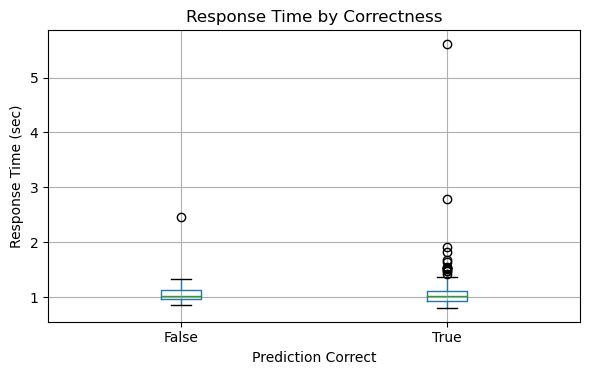

In [75]:
if "response_time_sec" in d.columns:
    d.boxplot(column="response_time_sec", by="correct", figsize=(6, 4))
    plt.title("Response Time by Correctness")
    plt.suptitle("")
    plt.xlabel("Prediction Correct")
    plt.ylabel("Response Time (sec)")
    plt.tight_layout()
    plt.savefig(
        "response_time_by_correctness.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

### 10. Inspect wrong cases

In [76]:
cols = [
    "story_index",
    "pair_index",
    "story_text",
    "original_action_a",
    "original_action_b",
    "input_action_a",
    "input_action_b",
    TRUE,
    PRED,
    SOURCE,
    "source_action",
    "target_action",
    "relation_direction",
    "llm_reason",
    "response_time_sec",
    "attempts",
    "status"
]

cols = [c for c in cols if c in d.columns]

wrong_cases = d[d[TRUE] != d[PRED]][cols]
wrong_cases.head(30)

,story_index,pair_index,story_text,original_action_a,original_action_b,input_action_a,input_action_b,True_label,predicted_relation,data_source,source_action,target_action,relation_direction,llm_reason,response_time_sec,attempts,status
3,64,3,"As a Publisher, I want to know if this site ha...",work out,have,work out,have,ENABLES,NONE,natural,NaN,NaN,NaN,These are parallel mental outcomes of knowing ...,1.058261,1,OK
4,20,4,"As a Publisher, I want to be able to preview t...",preview,using,preview,using,ENABLES,NONE,natural,NaN,NaN,NaN,These actions describe the execution method ra...,0.920789,1,OK
5,50,1,"As a Consumer, I want to browse and find publi...",browse,find,browse,find,ENABLES,NONE,natural,NaN,NaN,NaN,These are parallel actions within the browsing...,1.125578,1,OK
17,14,10,"As a Publisher, I want to publish a data packa...",stored,still have,stored,still have,ENABLES,NONE,natural,NaN,NaN,NaN,Storing data and having a copy are descriptive...,0.922572,1,OK
24,61,1,"As an Admin, I want to set key configuration p...",set,change,set,change,ENABLES,NONE,natural,NaN,NaN,NaN,These actions describe the same operation or a...,1.025555,1,OK
42,15,10,"As a Consumer, I want to be able to get the da...",still use,keeps working,still use,keeps working,ENABLES,NONE,natural,NaN,NaN,NaN,These are parallel results of the system funct...,0.847576,1,OK
64,33,6,As a Data Analyst I want to download a data pa...,study,infer,study,infer,ENABLES,NONE,natural,NaN,NaN,NaN,Studying is a cognitive process and not a func...,1.021197,1,OK
68,48,2,"As a Consumer, I want to be notified of change...",be notified,take action,be notified,take action,ENABLES,NONE,natural,NaN,NaN,NaN,"Notification provides information, but taking ...",1.023419,1,OK
73,14,19,"As a Publisher, I want to publish a data packa...",gets broken,still have,gets broken,still have,NONE,ENABLES,natural,gets broken,still have,A_TO_B,The loss or breakage of data acts as the condi...,1.021517,1,OK
74,27,2,"As a Consumer, I want to see some example data...",see,look further,see,look further,NONE,ENABLES,natural,see,look further,A_TO_B,Seeing the example data acts as the necessary ...,1.123858,1,OK


### 11. Wrong examples per error type

In [77]:
top_error_examples = (
    d[d[TRUE] != d[PRED]]
    .groupby([TRUE, PRED], group_keys=False)
    .head(3)
)

top_error_examples[cols]

,story_index,pair_index,story_text,original_action_a,original_action_b,input_action_a,input_action_b,True_label,predicted_relation,data_source,source_action,target_action,relation_direction,llm_reason,response_time_sec,attempts,status
3,64,3,"As a Publisher, I want to know if this site ha...",work out,have,work out,have,ENABLES,NONE,natural,NaN,NaN,NaN,These are parallel mental outcomes of knowing ...,1.058261,1,OK
4,20,4,"As a Publisher, I want to be able to preview t...",preview,using,preview,using,ENABLES,NONE,natural,NaN,NaN,NaN,These actions describe the execution method ra...,0.920789,1,OK
5,50,1,"As a Consumer, I want to browse and find publi...",browse,find,browse,find,ENABLES,NONE,natural,NaN,NaN,NaN,These are parallel actions within the browsing...,1.125578,1,OK
73,14,19,"As a Publisher, I want to publish a data packa...",gets broken,still have,gets broken,still have,NONE,ENABLES,natural,gets broken,still have,A_TO_B,The loss or breakage of data acts as the condi...,1.021517,1,OK
74,27,2,"As a Consumer, I want to see some example data...",see,look further,see,look further,NONE,ENABLES,natural,see,look further,A_TO_B,Seeing the example data acts as the necessary ...,1.123858,1,OK
75,25,3,"As a Consumer, I want to see how much the data...",choose,downloaded,choose,downloaded,NONE,ENABLES,natural,downloaded,choose,B_TO_A,Knowing the download amount is a prerequisite ...,1.019423,1,OK


### 12. Correct examples per class

In [78]:
correct_examples = (
    d[d[TRUE] == d[PRED]]
    .groupby(TRUE, group_keys=False)
    .head(3)
)

correct_examples[cols]

,story_index,pair_index,story_text,original_action_a,original_action_b,input_action_a,input_action_b,True_label,predicted_relation,data_source,source_action,target_action,relation_direction,llm_reason,response_time_sec,attempts,status
0,51,1,"As a Consumer, I want to see a publisher's pro...",see,discover,see,discover,ENABLES,ENABLES,natural,see,discover,A_TO_B,Seeing the profile provides the necessary info...,1.197064,1,OK
1,49,1,"As a Consumer, I want to see how active the si...",see,decide,see,decide,ENABLES,ENABLES,natural,see,decide,A_TO_B,Seeing site activity provides the necessary in...,1.029081,1,OK
2,46,1,"As a Consumer, I want to view a Datapackage at...",view,present,view,present,ENABLES,ENABLES,natural,view,present,A_TO_B,Viewing the datapackage is a functional prereq...,1.022044,1,OK
76,20,7,"As a Publisher, I want to be able to preview t...",publishing,using,publishing,using,NONE,NONE,natural,NaN,NaN,NaN,These are parallel activities; the CLI usage d...,1.029073,1,OK
77,15,5,"As a Consumer, I want to be able to get the da...",moved,removed,moved,removed,NONE,NONE,natural,NaN,NaN,NaN,The actions describe parallel or alternative s...,0.935201,1,OK
78,51,2,"As a Consumer, I want to see a publisher's pro...",see,get,see,get,NONE,NONE,natural,NaN,NaN,NaN,These are parallel exploratory actions; seeing...,0.918654,1,OK
146,0,1,"As a Publisher, I want to lock a dataset to a ...",lock,view,lock,view,BLOCKS,BLOCKS,synthetic,lock,view,A_TO_B,"Locking the dataset restricts access, creating...",0.944224,1,OK
147,1,1,"As a Publisher, I want to archive a dataset so...",archive a dataset,download it,archive a dataset,download it,BLOCKS,BLOCKS,synthetic,archive a dataset,download it,A_TO_B,Archiving the dataset establishes a state that...,0.822544,1,OK
148,2,1,"As a registry admin, I want to reject a publis...",reject,publish,reject,publish,BLOCKS,BLOCKS,synthetic,reject,publish,A_TO_B,Rejecting the account creates a restriction th...,0.914156,1,OK
